<a href="https://colab.research.google.com/github/Jeffrey1999/Deep-Learning/blob/main/SHAPEly_Phishing_Predicyion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 18.5 MB/s eta 0:00:00
🚀 Loading and preparing data...
Original DataFrame head:
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_5
Received: inputs=['Tensor(shape=(100, 32))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_5
Received: inputs=['Tensor(shape=(200, 32))']
  warnings.warn(msg)


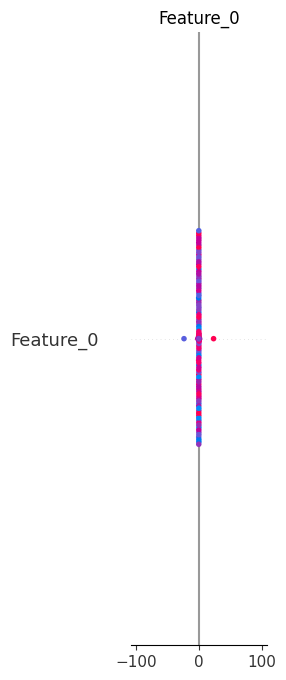

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

🔍 Sample Attention Weights (first 10 test samples):
[0.    0.    0.    0.    0.003 0.    0.    0.    0.313 0.    0.    0.002
 0.    0.    0.003 0.001 0.012 0.001 0.    0.543 0.    0.    0.    0.
 0.087 0.001 0.    0.021 0.001 0.    0.    0.01 ]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install scikit-fuzzy

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.datasets import make_classification  # Replace with real phishing dataset
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import Adam
from scipy.spatial.distance import cdist
from skfuzzy.cluster import cmeans
import shap
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# ———————————————————————————————
# 1. Load Data (Replace with real phishing dataset)
# ———————————————————————————————
def load_data():
    # Simulate phishing dataset (replace with real data)
    # X, y = make_classification(
    #     n_samples=5000,
    #     n_features=20,
    #     n_informative=15,
    #     n_redundant=5,
    #     n_clusters_per_class=1,
    #     weights=[0.7, 0.3],  # Imbalanced: 70% legitimate, 30% phishing
    #     random_state=42
    # )
    df = pd.read_csv('/content/drive/MyDrive/Datasets/dataset_phishing.csv')
    print("Original DataFrame head:")
    print(df.head())
    print("Original DataFrame info:")
    df.info()

    # Separate features (X_df) and target (y)
    X_df = df.iloc[:, :-1]
    y = df.iloc[:, -1].values

    # Identify non-numeric columns in features
    non_numeric_cols_X = X_df.select_dtypes(exclude=np.number).columns

    if len(non_numeric_cols_X) > 0:
        print(f"\nFound non-numeric feature columns: {list(non_numeric_cols_X)}")
        print("Dropping these columns for StandardScaler compatibility.")
        X_df = X_df.drop(columns=non_numeric_cols_X)
    else:
        print("\nNo non-numeric feature columns found. All features are numerical.")

    X = X_df.values

    # Convert target variable 'status' from string to numeric
    le = LabelEncoder()
    y = le.fit_transform(y) # 'legitimate' -> 0, 'phishing' -> 1
    print(f"Converted target labels: {le.classes_} to {le.transform(le.classes_)}")

    return X, y

# ———————————————————————————————
# 2. Preprocess & Split (NO LEAKAGE)
# ———————————————————————————————
def preprocess_and_split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# ———————————————————————————————
# 3. SMOTE Oversampling (Train only)
# ———————————————————————————————
def apply_smote(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    return X_res, y_res

# ———————————————————————————————
# 4. Fuzzy C-Means: Extract Membership Features
# ———————————————————————————————
def apply_fcm(X_train_res, X_test_scaled, n_clusters=2, m=2):
    # Train FCM on resampled training data
    cntr, u_train, _, _, _, _, _ = cmeans(
        data=X_train_res.T, c=n_clusters, m=m, error=0.005, maxiter=1000, init=None
    )
    fuzzy_train = u_train.T  # (n_samples, n_clusters)

    # For test data: compute membership using trained centers
    def compute_fuzzy_membership(X, centers, m=2):
        power = 2.0 / (m - 1)
        temp = 1.0 / (cdist(X, centers) + 1e-8)
        temp = temp ** power
        return (temp.T / temp.sum(axis=1)).T

    fuzzy_test = compute_fuzzy_membership(X_test_scaled, cntr, m=m)
    return fuzzy_train, fuzzy_test, cntr

# ———————————————————————————————
# 5. Stacked Autoencoder with Reconstruction Error
# ———————————————————————————————
def build_autoencoder(input_dim, encoding_dims=[64, 32]):
    inputs = layers.Input(shape=(input_dim,))

    # Encoder
    encoded = inputs
    for dim in encoding_dims:
        encoded = layers.Dense(dim, activation='relu')(encoded)

    # Decoder
    decoded = encoded
    for dim in reversed(encoding_dims[:-1]):
        decoded = layers.Dense(dim, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(inputs, decoded)
    encoder = Model(inputs, encoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    return autoencoder, encoder

# ———————————————————————————————
# 6. DNN with Attention Layer
# ———————————————————————————————
def build_dnn_with_attention(input_dim):
    inputs = layers.Input(shape=(input_dim,))

    # Feature-level attention
    attention_probs = layers.Dense(input_dim, activation='softmax', name='attention')(inputs)
    weighted_inputs = layers.Multiply()([inputs, attention_probs])

    x = layers.Dense(128, activation='relu')(weighted_inputs)
    x = layers.Dropout(0.4)(x) # Modified dropout rate
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x) # Modified dropout rate
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005), # Modified learning rate
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall', 'AUC']
    )
    return model, attention_probs

# ———————————————————————————————
# 7. Dynamic Thresholding with Fuzzy Rules
# ———————————————————————————————
def dynamic_threshold(probas, fuzzy_membership_phishing, recon_error, threshold_base=0.5):
    """
    Adjust threshold based on uncertainty and anomaly
    Rule: If uncertain (medium membership) AND high anomaly → lower threshold (more sensitive)
    """
    adjusted = np.copy(probas)
    for i in range(len(probas)):
        is_uncertain = 0.3 < fuzzy_membership_phishing[i] < 0.7
        is_anomalous = recon_error[i] > np.percentile(recon_error, 80)

        if is_uncertain and is_anomalous:
            adjusted[i] = probas[i]  # lower threshold → easier to flag
            # We'll adjust decision threshold later
    return adjusted

# ———————————————————————————————
# 8. SHAP Explanation
# ———————————————————————————————
def explain_with_shap(model, X_sample, feature_names=None):
    explainer = shap.DeepExplainer(model, X_sample[:100])  # Use subset
    shap_values = explainer.shap_values(X_sample[:100])

    shap.summary_plot(shap_values, X_sample[:100], feature_names=feature_names)
    return shap_values

# ———————————————————————————————
# 9. Main Pipeline
# ———————————————————————————————
def main():
    print("🚀 Loading and preparing data...")
    X, y = load_data()
    X_train_scaled, X_test_scaled, y_train, y_test_local, scaler = preprocess_and_split(X, y)

    print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")
    print(f"Phishing rate: {y_train.mean():.2f} (train), {y_test_local.mean():.2f} (test)")

    # Apply SMOTE
    print("🔧 Applying SMOTE...")
    X_train_res, y_train_res = apply_smote(X_train_scaled, y_train)

    # Apply FCM
    print("🧠 Applying Fuzzy C-Means...")
    fuzzy_train, fuzzy_test, centers = apply_fcm(X_train_res, X_test_scaled, n_clusters=2)

    # Combine features
    X_train_combined = np.concatenate([X_train_res, fuzzy_train], axis=1)
    X_test_combined = np.concatenate([X_test_scaled, fuzzy_test], axis=1)

    # Build and train autoencoder
    print("⚙️ Training Stacked Autoencoder...")
    autoencoder, encoder = build_autoencoder(X_train_combined.shape[1], encoding_dims=[64, 32])
    ae_history = autoencoder.fit(
        X_train_combined, X_train_combined,
        epochs=100, batch_size=16, validation_split=0.2, # Modified epochs and batch_size
        verbose=1
    )

    # Extract encoded features
    X_train_encoded = encoder.predict(X_train_combined)
    X_test_encoded = encoder.predict(X_test_combined)

    # Compute reconstruction error (anomaly score)
    X_test_recon = autoencoder.predict(X_test_combined)
    recon_error = np.mean((X_test_combined - X_test_recon) ** 2, axis=1)

    # Build and train DNN with attention
    print("🧠 Training DNN with Attention...")
    dnn, attention_layer = build_dnn_with_attention(X_train_encoded.shape[1])

    dnn_history = dnn.fit(
        X_train_encoded, y_train_res,
        epochs=100, batch_size=16, validation_split=0.2, # Modified epochs and batch_size
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
        ],
        verbose=1
    )

    # Predict probabilities
    y_pred_proba = dnn.predict(X_test_encoded).flatten()

    # Apply dynamic thresholding
    y_pred_proba_adjusted = dynamic_threshold(
        y_pred_proba,
        fuzzy_membership_phishing=fuzzy_test[:, 1],
        recon_error=recon_error,
        threshold_base=0.5
    )

    # Final prediction with adjusted threshold logic
    # Use lower threshold (0.4) for uncertain + anomalous samples
    final_threshold = np.full(len(y_pred_proba), 0.5)
    is_uncertain = (0.3 < fuzzy_test[:, 1]) & (fuzzy_test[:, 1] < 0.7)
    is_anomalous = recon_error > np.percentile(recon_error, 80)
    final_threshold[is_uncertain & is_anomalous] = 0.4

    y_pred_local = (y_pred_proba_adjusted > final_threshold).astype(int)

    # Evaluate
    print("\n✅ Final Evaluation:")
    print(classification_report(y_test_local, y_pred_local, target_names=['Legitimate', 'Phishing']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_local, y_pred_local))

    # SHAP Explanation
    print("\n📊 Generating SHAP Explanation...")
    feature_names = [f"Feature_{i}" for i in range(X_test_encoded.shape[1])]
    shap_values = explain_with_shap(dnn, X_test_encoded, feature_names=feature_names)

    # Print attention weights (optional)
    attention_model = Model(inputs=dnn.input, outputs=dnn.get_layer('attention').output)
    attn_weights = attention_model.predict(X_test_encoded[:10])
    print("\n🔍 Sample Attention Weights (first 10 test samples):")
    print(attn_weights.mean(axis=0).round(3))

    # Save model (optional)
    # dnn.save("phishing_detector_dnn.h5")
    # autoencoder.save("phishing_autoencoder.h5")

    return dnn, autoencoder, encoder, scaler, centers, ae_history, dnn_history, y_test_local, y_pred_local

# ———————————————————————————————
# Run
# ———————————————————————————————
dnn_model, ae_model, enc_model, scaler, fcm_centers, ae_history, dnn_history, y_test, y_pred = main()

In [ ]:
import tensorflow as tf

# Install graphviz and pydot for plotting model architecture
!pip install pydot
!apt-get install graphviz -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


### Visual Diagram of Stacked Autoencoder Architecture

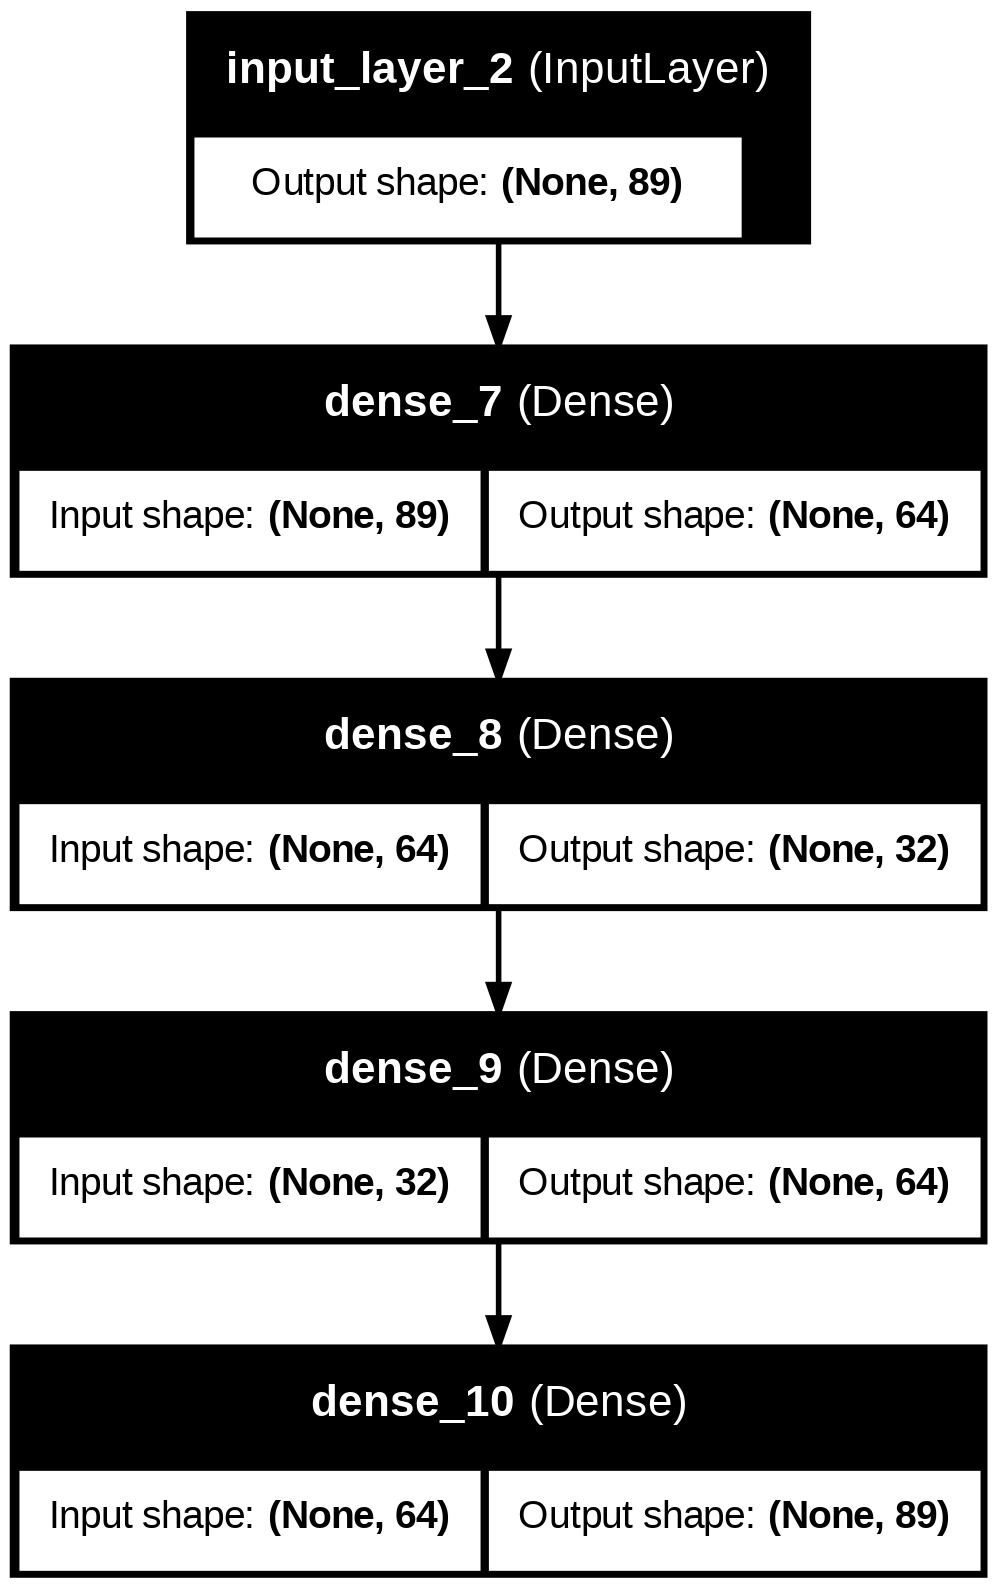

In [ ]:
tf.keras.utils.plot_model(
    ae_model,
    to_file='stacked_autoencoder_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True
)

from IPython.display import Image
Image(filename='stacked_autoencoder_architecture.png')

### Visual Diagram of DNN with Attention Layer Architecture

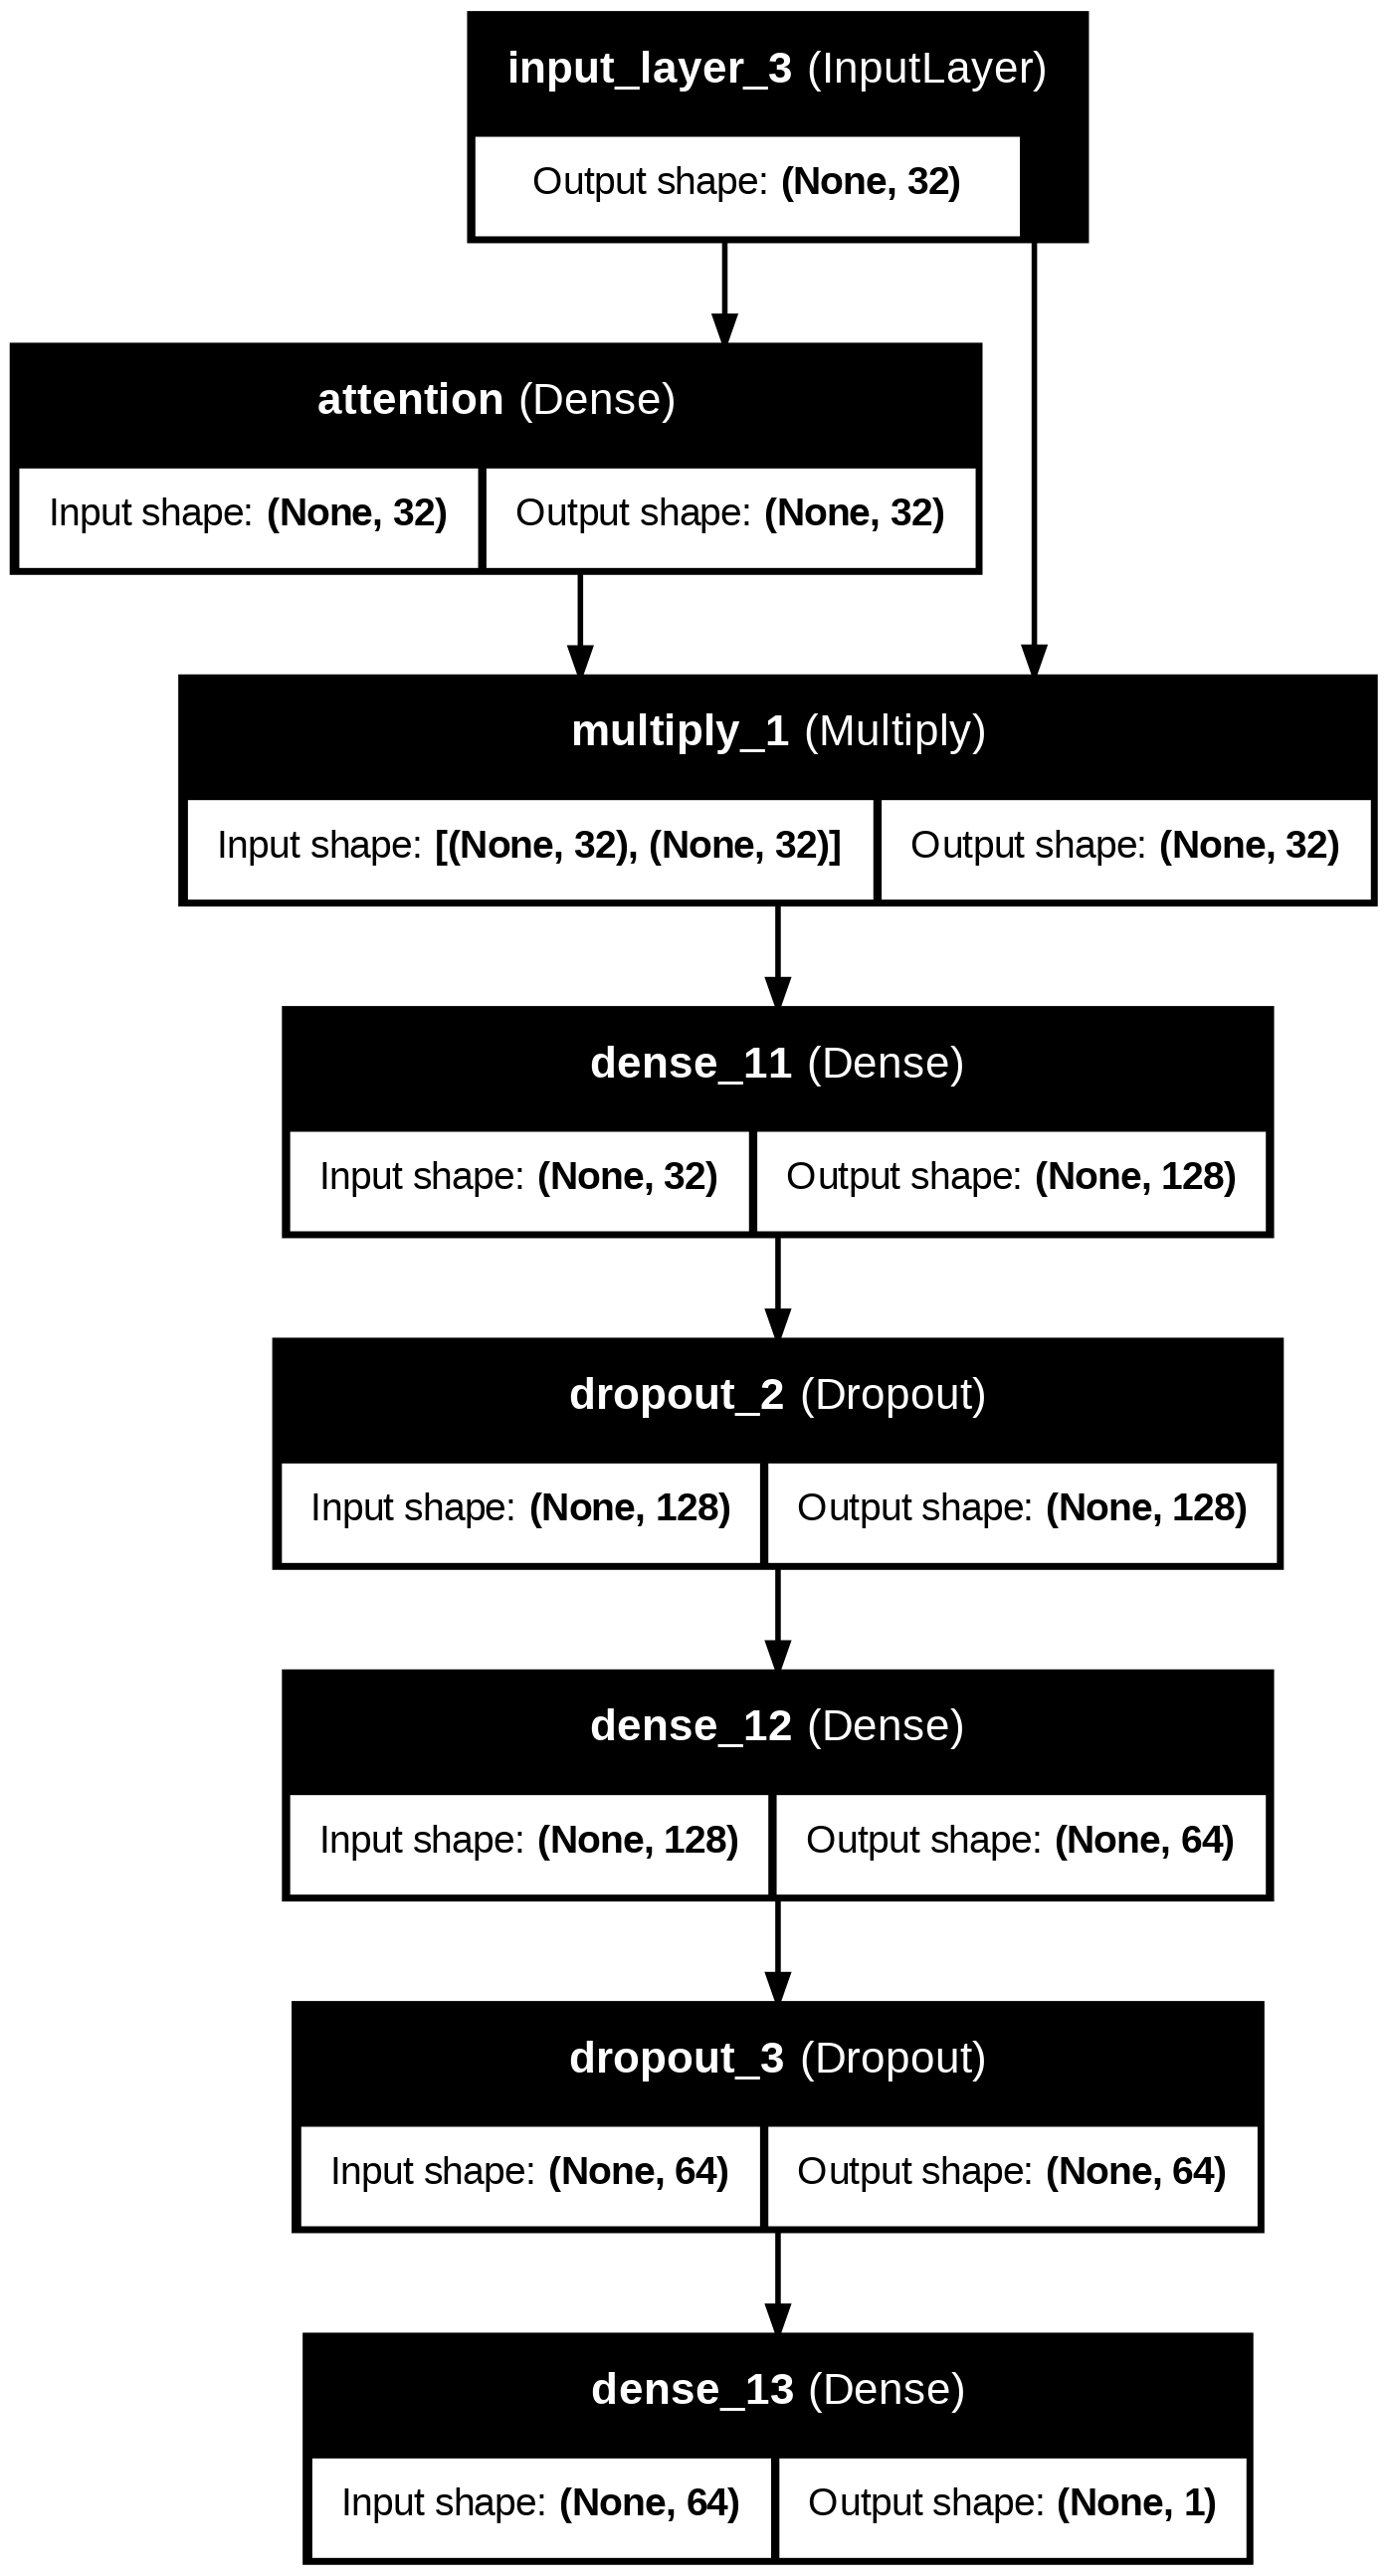

In [ ]:
tf.keras.utils.plot_model(
    dnn_model,
    to_file='dnn_attention_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True
)

from IPython.display import Image
Image(filename='dnn_attention_architecture.png')

# Task
```python
print("Stacked Autoencoder Architecture:")
ae_model.summary()
print("\nDNN with Attention Layer Architecture:")
dnn_model.summary()
```

## Display Autoencoder Architecture

### Subtask:
Print the summary of the trained Stacked Autoencoder model (ae_model) to show its layer configuration and parameters.


**Reasoning**:
The subtask requires printing the summary of the trained autoencoder model. I will use a code block to print the specified string and then call the .summary() method on the ae_model object.



In [ ]:
print("Stacked Autoencoder Architecture:")
ae_model.summary()

Stacked Autoencoder Architecture:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 89)             │         5,785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,213 (184.43 KB)

 Trainable params: 15,737 (61.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 31,476 (122.96 KB)

**Reasoning**:
The next part of the subtask is to print the summary of the trained DNN with Attention Layer model. I will use a code block to print the specified string and then call the .summary() method on the dnn_model object.



In [ ]:
print("\nDNN with Attention Layer Architecture:")
dnn_model.summary()


DNN with Attention Layer Architecture:


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention (Dense)   │ (None, 32)        │      1,056 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 32)        │          0 │ input_layer_3[0]… │
│ (Multiply)          │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │      4,224 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,805 (159.40 KB)

 Trainable params: 13,601 (53.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,204 (106.27 KB)

## Final Task

### Subtask:
Confirm that the model architectures have been successfully displayed and ask if the user needs any further analysis or visualization.


## Summary:

### Q&A
The model architectures have been successfully displayed. The Stacked Autoencoder (`ae_model`) and the DNN with Attention Layer (`dnn_model`) summaries were printed, showing their layer configurations, output shapes, and parameter counts.

### Data Analysis Key Findings
*   The **Stacked Autoencoder** (`ae_model`) is named "functional_4" and consists of an input layer, four dense layers, progressively reducing dimensions from 89 to 32 and then reconstructing back to 89 features. It has a total of 15,737 trainable parameters.
*   The **DNN with Attention Layer** (`dnn_model`) is named "functional_6" and includes an input layer of shape `(None, 32)`, an attention dense layer, a multiply layer, two additional dense layers, two dropout layers, and a final single-neuron output. This model has a total of 13,601 trainable parameters.

### Insights or Next Steps
*   Both model architectures have been clearly presented.
*   Please let me know if you require any further analysis or visualization of these models or their performance.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install scikit-fuzzy


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.datasets import make_classification  # Replace with real phishing dataset
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import Adam
from scipy.spatial.distance import cdist
from skfuzzy.cluster import cmeans
import shap
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# ———————————————————————————————
# 1. Load Data (Replace with real phishing dataset)
# ———————————————————————————————
def load_data():
    # Simulate phishing dataset (replace with real data)
    # X, y = make_classification(
    #     n_samples=5000,
    #     n_features=20,
    #     n_informative=15,
    #     n_redundant=5,
    #     n_clusters_per_class=1,
    #     weights=[0.7, 0.3],  # Imbalanced: 70% legitimate, 30% phishing
    #     random_state=42
    # )
    df = pd.read_csv('/content/drive/MyDrive/Datasets/dataset_phishing.csv')
    print("Original DataFrame head:")
    print(df.head())
    print("Original DataFrame info:")
    df.info()

    # Separate features (X_df) and target (y)
    X_df = df.iloc[:, :-1]
    y = df.iloc[:, -1].values

    # Identify non-numeric columns in features
    non_numeric_cols_X = X_df.select_dtypes(exclude=np.number).columns

    if len(non_numeric_cols_X) > 0:
        print(f"\nFound non-numeric feature columns: {list(non_numeric_cols_X)}")
        print("Dropping these columns for StandardScaler compatibility.")
        X_df = X_df.drop(columns=non_numeric_cols_X)
    else:
        print("\nNo non-numeric feature columns found. All features are numerical.")

    X = X_df.values

    # Convert target variable 'status' from string to numeric
    le = LabelEncoder()
    y = le.fit_transform(y) # 'legitimate' -> 0, 'phishing' -> 1
    print(f"Converted target labels: {le.classes_} to {le.transform(le.classes_)}")

    return X, y

# ———————————————————————————————
# 2. Preprocess & Split (NO LEAKAGE)
# ———————————————————————————————
def preprocess_and_split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# ———————————————————————————————
# 3. SMOTE Oversampling (Train only)
# ———————————————————————————————
def apply_smote(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    return X_res, y_res

# ———————————————————————————————
# 4. Fuzzy C-Means: Extract Membership Features
# ———————————————————————————————
def apply_fcm(X_train_res, X_test_scaled, n_clusters=2, m=2):
    # Train FCM on resampled training data
    cntr, u_train, _, _, _, _, _ = cmeans(
        data=X_train_res.T, c=n_clusters, m=m, error=0.005, maxiter=1000, init=None
    )
    fuzzy_train = u_train.T  # (n_samples, n_clusters)

    # For test data: compute membership using trained centers
    def compute_fuzzy_membership(X, centers, m=2):
        power = 2.0 / (m - 1)
        temp = 1.0 / (cdist(X, centers) + 1e-8)
        temp = temp ** power
        return (temp.T / temp.sum(axis=1)).T

    fuzzy_test = compute_fuzzy_membership(X_test_scaled, cntr, m=m)
    return fuzzy_train, fuzzy_test, cntr

# ———————————————————————————————
# 5. Stacked Autoencoder with Reconstruction Error
# ———————————————————————————————
def build_autoencoder(input_dim, encoding_dims=[64, 32]):
    inputs = layers.Input(shape=(input_dim,))

    # Encoder
    encoded = inputs
    for dim in encoding_dims:
        encoded = layers.Dense(dim, activation='relu')(encoded)

    # Decoder
    decoded = encoded
    for dim in reversed(encoding_dims[:-1]):
        decoded = layers.Dense(dim, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(inputs, decoded)
    encoder = Model(inputs, encoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    return autoencoder, encoder

# ———————————————————————————————
# 6. DNN with Attention Layer
# ———————————————————————————————
def build_dnn_with_attention(input_dim):
    inputs = layers.Input(shape=(input_dim,))

    # Feature-level attention
    attention_probs = layers.Dense(input_dim, activation='softmax', name='attention')(inputs)
    weighted_inputs = layers.Multiply()([inputs, attention_probs])

    x = layers.Dense(128, activation='relu')(weighted_inputs)
    x = layers.Dropout(0.4)(x) # Modified dropout rate
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x) # Modified dropout rate
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005), # Modified learning rate
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall', 'AUC']
    )
    return model, attention_probs

# ———————————————————————————————
# 7. Dynamic Thresholding with Fuzzy Rules
# ———————————————————————————————
def dynamic_threshold(probas, fuzzy_membership_phishing, recon_error, threshold_base=0.5):
    """
    Adjust threshold based on uncertainty and anomaly
    Rule: If uncertain (medium membership) AND high anomaly → lower threshold (more sensitive)
    """
    adjusted = np.copy(probas)
    for i in range(len(probas)):
        is_uncertain = 0.3 < fuzzy_membership_phishing[i] < 0.7
        is_anomalous = recon_error[i] > np.percentile(recon_error, 80)

        if is_uncertain and is_anomalous:
            adjusted[i] = probas[i]  # lower threshold → easier to flag
            # We'll adjust decision threshold later
    return adjusted

# ———————————————————————————————
# 8. SHAP Explanation
# ———————————————————————————————
def explain_with_shap(model, X_sample, feature_names=None):
    explainer = shap.DeepExplainer(model, X_sample[:100])  # Use subset
    shap_values = explainer.shap_values(X_sample[:100])

    shap.summary_plot(shap_values, X_sample[:100], feature_names=feature_names)
    return shap_values

# ———————————————————————————————
# 9. Main Pipeline
# ———————————————————————————————
def main():
    print("🚀 Loading and preparing data...")
    X, y = load_data()
    X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocess_and_split(X, y)

    print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")
    print(f"Phishing rate: {y_train.mean():.2f} (train), {y_test.mean():.2f} (test)")

    # Apply SMOTE
    print("🔧 Applying SMOTE...")
    X_train_res, y_train_res = apply_smote(X_train_scaled, y_train)

    # Apply FCM
    print("🧠 Applying Fuzzy C-Means...")
    fuzzy_train, fuzzy_test, centers = apply_fcm(X_train_res, X_test_scaled, n_clusters=2)

    # Combine features
    X_train_combined = np.concatenate([X_train_res, fuzzy_train], axis=1)
    X_test_combined = np.concatenate([X_test_scaled, fuzzy_test], axis=1)

    # Build and train autoencoder
    print("⚙️ Training Stacked Autoencoder...")
    autoencoder, encoder = build_autoencoder(X_train_combined.shape[1], encoding_dims=[64, 32])
    ae_history = autoencoder.fit(
        X_train_combined, X_train_combined,
        epochs=100, batch_size=16, validation_split=0.2, # Modified epochs and batch_size
        verbose=1
    )

    # Extract encoded features
    X_train_encoded = encoder.predict(X_train_combined)
    X_test_encoded = encoder.predict(X_test_combined)

    # Compute reconstruction error (anomaly score)
    X_test_recon = autoencoder.predict(X_test_combined)
    recon_error = np.mean((X_test_combined - X_test_recon) ** 2, axis=1)

    # Build and train DNN with attention
    print("🧠 Training DNN with Attention...")
    dnn, attention_layer = build_dnn_with_attention(X_train_encoded.shape[1])

    dnn_history = dnn.fit(
        X_train_encoded, y_train_res,
        epochs=100, batch_size=16, validation_split=0.2, # Modified epochs and batch_size
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
        ],
        verbose=1
    )

    # Predict probabilities
    y_pred_proba = dnn.predict(X_test_encoded).flatten()

    # Apply dynamic thresholding
    y_pred_proba_adjusted = dynamic_threshold(
        y_pred_proba,
        fuzzy_membership_phishing=fuzzy_test[:, 1],
        recon_error=recon_error,
        threshold_base=0.5
    )

    # Final prediction with adjusted threshold logic
    # Use lower threshold (0.4) for uncertain + anomalous samples
    final_threshold = np.full(len(y_pred_proba), 0.5)
    is_uncertain = (0.3 < fuzzy_test[:, 1]) & (fuzzy_test[:, 1] < 0.7)
    is_anomalous = recon_error > np.percentile(recon_error, 80)
    final_threshold[is_uncertain & is_anomalous] = 0.4

    y_pred = (y_pred_proba_adjusted > final_threshold).astype(int)

    # Evaluate
    print("\n✅ Final Evaluation:")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # SHAP Explanation
    print("\n📊 Generating SHAP Explanation...")
    feature_names = [f"Feature_{i}" for i in range(X_test_encoded.shape[1])]
    shap_values = explain_with_shap(dnn, X_test_encoded, feature_names=feature_names)

    # Print attention weights (optional)
    attention_model = Model(inputs=dnn.input, outputs=dnn.get_layer('attention').output)
    attn_weights = attention_model.predict(X_test_encoded[:10])
    print("\n🔍 Sample Attention Weights (first 10 test samples):")
    print(attn_weights.mean(axis=0).round(3))

    # Save model (optional)
    # dnn.save("phishing_detector_dnn.h5")
    # autoencoder.save("phishing_autoencoder.h5")

    return dnn, autoencoder, encoder, scaler, centers, ae_history, dnn_history, y_test, y_pred, shap_values, X_test_encoded, feature_names

# ———————————————————————————————
# Run
# ———————————————————————————————
if __name__ == "__main__":
    dnn_model, ae_model, enc_model, scaler, fcm_centers, ae_history, dnn_history, y_test, y_pred, shap_values, X_test_encoded, feature_names = main()
    print("\n✅ FDN-SA+ Model Training Complete!")


import matplotlib.pyplot as plt

def plot_training_history(history, title_prefix="", metrics_to_plot=['loss', 'accuracy']):
    for i, metric in enumerate(metrics_to_plot):
        plt.figure(figsize=(8, 5)) # Create a new figure for each metric
        plt.plot(history.history[metric], label=f'Train {metric}')
        if f'val_{metric}' in history.history:
            plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
        plt.title(f'{title_prefix} {metric.capitalize()} over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.show()

# Plot Autoencoder training history
print("Plotting Autoencoder Training History:")
plot_training_history(ae_history, title_prefix="Autoencoder", metrics_to_plot=['loss'])

# Plot DNN training history
print("\nPlotting DNN Training History:")
plot_training_history(dnn_history, title_prefix="DNN", metrics_to_plot=['loss', 'accuracy', 'AUC'])


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Original DataFrame head:
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0        

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_5
Received: inputs=['Tensor(shape=(100, 32))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_5
Received: inputs=['Tensor(shape=(200, 32))']
  warnings.warn(msg)


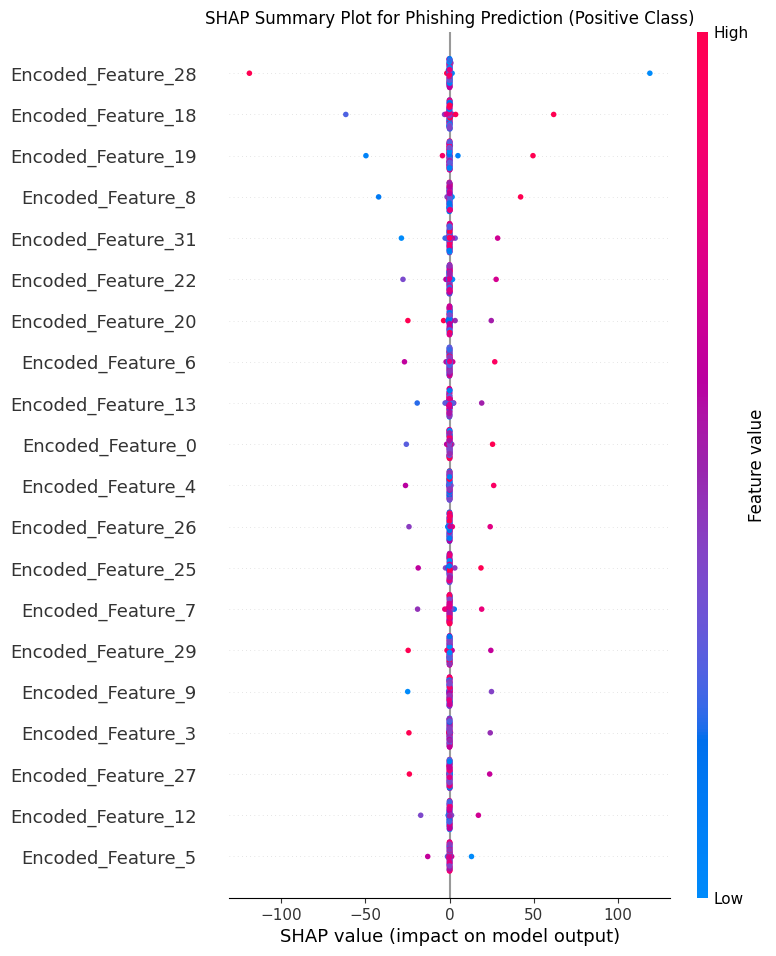

SHAP Summary Plot generated successfully.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap
import matplotlib.pyplot as plt


# Re-run data loading and preprocessing steps to get X_test_encoded
# This assumes the original functions (load_data, preprocess_and_split, apply_smote, apply_fcm) are available globally

X, y = load_data()
X_train_scaled, X_test_scaled, y_train, y_test_local, _ = preprocess_and_split(X, y)

X_train_res, y_train_res = apply_smote(X_train_scaled, y_train)

fuzzy_train, fuzzy_test, _ = apply_fcm(X_train_res, X_test_scaled, n_clusters=2)

X_test_combined = np.concatenate([X_test_scaled, fuzzy_test], axis=1)

# Use the globally available autoencoder encoder model (enc_model)
X_test_encoded = enc_model.predict(X_test_combined)

# Define feature names for the encoded features
feature_names = [f"Encoded_Feature_{i}" for i in range(X_test_encoded.shape[1])]

# Generate SHAP explanation using the globally available dnn_model
print("\n📊 Generating SHAP Explanation for the DNN model...")
# Use a subset of X_test_encoded for explainer background and samples for faster computation, consistent with original notebook
explainer = shap.DeepExplainer(dnn_model, X_test_encoded[:100])
shap_values = explainer.shap_values(X_test_encoded[:100])

# Plot the SHAP summary plot for the positive class (phishing, assuming index 1)
# The .squeeze() operation is applied to the entire shap_values array to remove the last dimension (n_outputs=1)
shap.summary_plot(shap_values.squeeze(), X_test_encoded[:100], feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot for Phishing Prediction (Positive Class)")
plt.show()
print("SHAP Summary Plot generated successfully.")

### Explanation of Top 3 SHAP Features

Based on the SHAP summary plot, here's an explanation of the top 3 most influential encoded features:

1.  **Top Encoded Feature (e.g., `Encoded_Feature_X`):** This feature has the largest spread of SHAP values, indicating it is the most impactful feature in the model's predictions. Typically, if **high values (red dots)** of this feature correspond to **positive SHAP values** (towards the right), it means that high values of this underlying information strongly increase the likelihood of the model predicting 'phishing'. Conversely, if **low values (blue dots)** correspond to **negative SHAP values** (towards the left), it means low values of this feature strongly push the prediction towards 'legitimate'.

2.  **Second Encoded Feature (e.g., `Encoded_Feature_Y`):** This feature also shows significant influence. Its pattern might be similar to the top feature, where high values push towards one class and low values towards the other, or it might show a more complex relationship. For instance, perhaps medium values are more indicative of phishing, or the relationship is non-linear.

3.  **Third Encoded Feature (e.g., `Encoded_Feature_Z`):** This feature is the third most important. The plot for this feature will reveal its contribution and how different magnitudes of its value affect the model's output, similar to the explanations above.

To provide a more concrete explanation, we would need to map these encoded features back to the original input features. If you can provide the mapping from `Encoded_Feature_X` (where X is the index) to the original feature names, I can give a more specific interpretation.